In [1]:
import torch
import torch.nn as nn
import numpy as np
import sklearn
from sklearn import datasets
from sklearn.preprocessing import StandardScaler  # for feature scaling
from sklearn.model_selection import train_test_split  # for train/test split

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sklearn.utils.validation.check_random_state(SEED)

RandomState(MT19937) at 0x7B062E785540

In [3]:
X = torch.arange(-5, 5, 0.1).view(-1, 1)
func = -5 * X

y = func + 10.4 * torch.randn(X.size())

X.shape, y.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

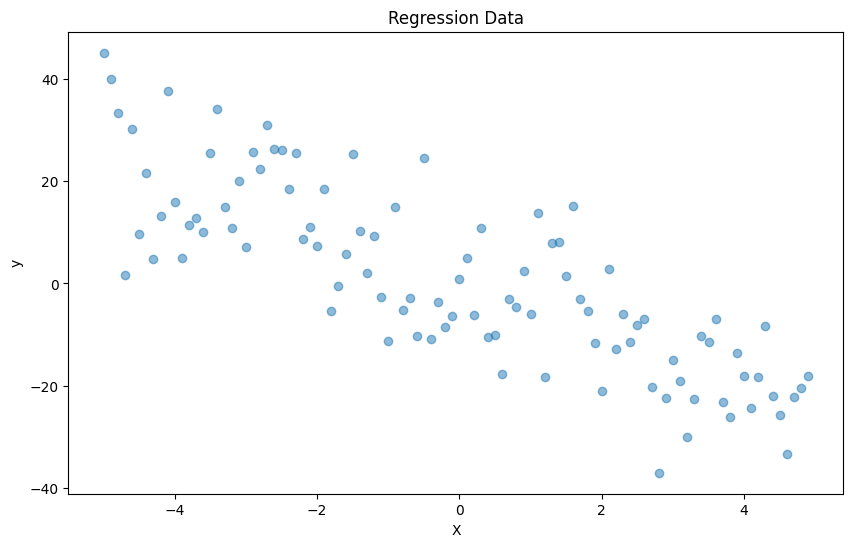

In [4]:
import matplotlib.pyplot as plt

def plot_linear_regression(X, y, model=None):
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, alpha=0.5)
    if model is not None:
        x_min = X.min()
        x_max = X.max()
        y_min = model(torch.tensor(x_min)).detach().numpy()
        y_max = model(torch.tensor(x_max)).detach().numpy()
        plt.plot([x_min, x_max], [y_min, y_max], color='red', linestyle='-')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Regression Data')

plot_linear_regression(X, y)

In [5]:
# Initialize trainable parameters
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

def model(x, a, b):
    return a * x + b


x_1 = torch.tensor(1.0)
model(x_1, a, b)

tensor(2., grad_fn=<AddBackward0>)

/tmp/ipykernel_431282/3261919473.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_min = model(torch.tensor(x_min)).detach().numpy()
/tmp/ipykernel_431282/3261919473.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_max = model(torch.tensor(x_max)).detach().numpy()


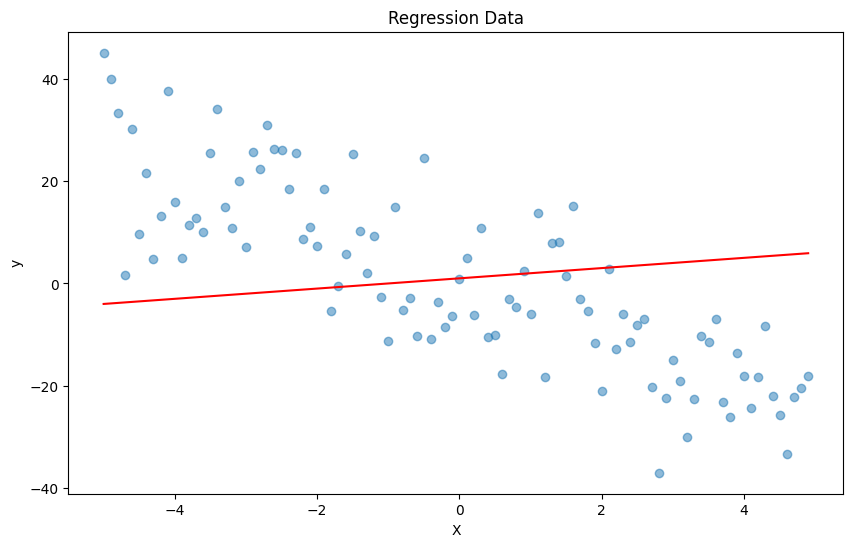

In [6]:
plot_linear_regression(X, y, lambda x: model(x, a, b))


In [7]:
def loss(y_pred, y_true):
    return (y_pred - y_true).pow(2).mean()


print(loss(model(X, a, b), y))

tensor(410.3479, grad_fn=<MeanBackward0>)


In [8]:
# Import optimizer
from torch import optim

# Initialize optimizer
optimizer = optim.SGD([a, b], lr=0.001)


In [10]:
# One step of training
y_pred = model(X, a, b)
l = loss(y_pred, y)

In [16]:
# y_pred.grad_fn
# l.grad_fn.next_functions
# l.grad_fn.next_functions[0][0].next_functions
# l.grad_fn.next_functions[0][0].next_functions[0][0].next_functions
# l.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions

In [17]:
a.grad, b.grad

(None, None)

In [18]:
# Backward pass
l.backward()


In [19]:
a.grad, b.grad

(tensor(101.0142), tensor(0.1569))

In [20]:
a, b

(tensor(1., requires_grad=True), tensor(1., requires_grad=True))

In [21]:
# Update parameters
optimizer.step()

# lr = 0.001
# a.data = a.data - lr * a.grad.data
# b.data = b.data - lr * b.grad.data

In [22]:
a, b

(tensor(0.8990, requires_grad=True), tensor(0.9998, requires_grad=True))

In [23]:
a.grad, b.grad

(tensor(101.0142), tensor(0.1569))

In [24]:
# Zero gradients
optimizer.zero_grad()


In [25]:
a.grad, b.grad

(None, None)

In [26]:
print(f"Loss after 1 step: {loss(model(X, a, b), y)}")

Loss after 1 step: 400.2290344238281


In [27]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

a.to(device)
b.to(device)
X.to(device)
y.to(device)

print(f"{device = }")

device = device(type='cuda')


Loss after 1 steps: 400.2290
Loss after 101 steps: 114.5221
Loss after 201 steps: 104.5829
Loss after 301 steps: 104.2135
Loss after 401 steps: 104.1839


Text(0.5, 1.0, 'Loss over training steps')

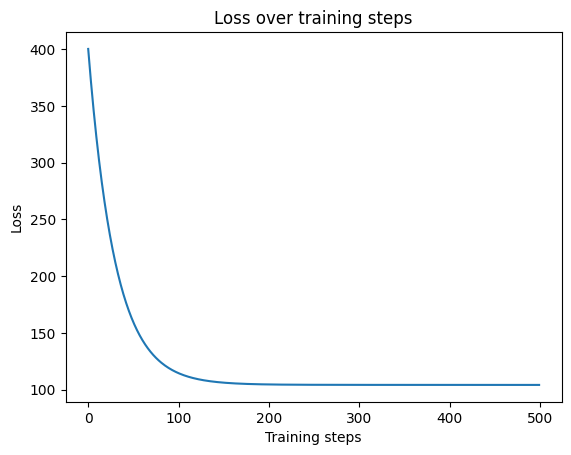

In [28]:
lr = 0.001
loss_history = []

for i in range(500):
    y_pred = model(X, a, b)
    l = loss(y_pred, y)

    optimizer.zero_grad()
    l.backward()

    a.data = a.data - (lr * a.grad.data)
    b.data = b.data - (lr * b.grad.data)
    # optimizer.step()

    loss_history.append(l.item())
    
    if i % 100 == 0:
        print(
            f"Loss after {i+1} steps: {l:.4f}"
            # f"\n"
            # f" da {a.grad.data:.4f} db {b.grad.data:.4f}\n"
            # f" a {a.data:.4f} b {b.data:.4f}\n"
        )

plt.plot(loss_history)
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Loss over training steps")

/tmp/ipykernel_431282/3261919473.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_min = model(torch.tensor(x_min)).detach().numpy()
/tmp/ipykernel_431282/3261919473.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_max = model(torch.tensor(x_max)).detach().numpy()


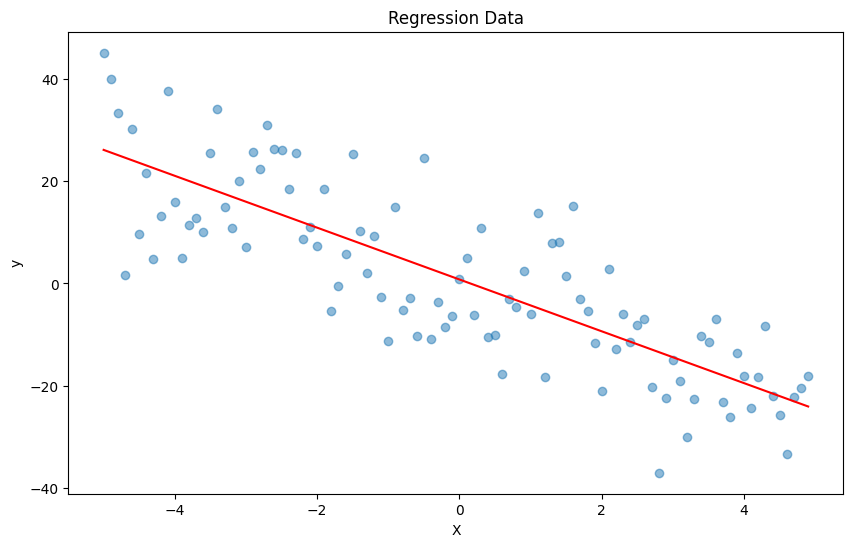

In [29]:
plot_linear_regression(X, y, lambda x: model(x, a, b))